# Naive Bayes with NumPy
Multinomial Naive Bayes for tweet sentiment using vectorised numpy operations.
Model saved to `../Models/naive_bayes_numpy.npz`.

## 1. Load & Preprocess Tweets

In [1]:
import nltk
nltk.download('twitter_samples', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import twitter_samples, stopwords
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re, os, random
from collections import Counter

STOPWORDS = set(stopwords.words('english'))

def clean(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return [t for t in text.split() if t not in STOPWORDS and len(t) > 1]

pos = twitter_samples.strings('positive_tweets.json')
neg = twitter_samples.strings('negative_tweets.json')

all_tokens = [clean(t) for t in pos + neg]
all_labels = [1]*len(pos) + [0]*len(neg)

combined = list(zip(all_tokens, all_labels))
random.seed(42)
random.shuffle(combined)
all_tokens, all_labels = zip(*combined)
all_tokens, all_labels = list(all_tokens), list(all_labels)

print(f"Total: {len(all_tokens):,}")

Total: 10,000


## 2. Train / Test Split (80/20)

In [2]:
split = int(len(all_tokens) * 0.8)
train_tokens, test_tokens = all_tokens[:split], all_tokens[split:]
y_train = np.array(all_labels[:split])
y_test  = np.array(all_labels[split:])

print(f"Train: {len(train_tokens):,}  Pos: {y_train.sum():,}  Neg: {(y_train==0).sum():,}")
print(f"Test : {len(test_tokens):,}  Pos: {y_test.sum():,}  Neg: {(y_test==0).sum():,}")

Train: 8,000  Pos: 3,994  Neg: 4,006
Test : 2,000  Pos: 1,006  Neg: 994


## 3. Build Vocabulary & Bag-of-Words Matrix

In [3]:
VOCAB_SIZE = 5000

freq     = Counter(tok for doc in train_tokens for tok in doc)
vocab    = [w for w, _ in freq.most_common(VOCAB_SIZE)]
word2idx = {w: i for i, w in enumerate(vocab)}
V        = len(vocab)

def bow_matrix(token_lists, word2idx, V):
    """Integer word-count matrix — shape (n_docs, V)."""
    X = np.zeros((len(token_lists), V), dtype=np.int32)
    for i, doc in enumerate(token_lists):
        for w in doc:
            if w in word2idx:
                X[i, word2idx[w]] += 1
    return X

print('Building BoW matrices...')
X_train = bow_matrix(train_tokens, word2idx, V)
X_test  = bow_matrix(test_tokens,  word2idx, V)
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

Building BoW matrices...
X_train: (8000, 5000)  |  X_test: (2000, 5000)


## 4. Train Multinomial Naive Bayes (NumPy)

**Log prior:**
$$\log P(c) = \log \frac{N_c}{N}$$

**Log likelihood with Laplace smoothing:**
$$\log P(w \mid c) = \log \frac{\text{count}(w, c) + 1}{\sum_{w'} \text{count}(w', c) + |V|}$$

**Log posterior for document d:**
$$\log P(c \mid d) \propto \log P(c) + X_d \cdot \log P(\mathbf{w} \mid c)$$

where $X_d$ is the word-count row vector for document $d$.
This dot product efficiently sums log-likelihoods for all words in the document.

In [4]:
def train_nb(X, y, V):
    """
    Returns:
      log_prior      : (2,)  — log P(c) for c in {0, 1}
      log_likelihood : (2, V) — log P(w | c) with Laplace smoothing
    """
    classes    = np.unique(y)
    n          = len(y)
    log_prior      = np.zeros(len(classes))
    log_likelihood = np.zeros((len(classes), V))

    for c in classes:
        X_c            = X[y == c]                           # docs of class c
        log_prior[c]   = np.log(len(X_c) / n)               # log P(c)
        word_counts    = X_c.sum(axis=0)                     # (V,)  total counts per word
        total          = word_counts.sum()                   # total tokens in class c
        log_likelihood[c] = np.log((word_counts + 1) / (total + V))  # Laplace

    return log_prior, log_likelihood


log_prior, log_likelihood = train_nb(X_train, y_train, V)

print(f"log P(neg=0): {log_prior[0]:.4f}  →  P = {np.exp(log_prior[0]):.4f}")
print(f"log P(pos=1): {log_prior[1]:.4f}  →  P = {np.exp(log_prior[1]):.4f}")
print(f"log_likelihood shape: {log_likelihood.shape}")

log P(neg=0): -0.6916  →  P = 0.5008
log P(pos=1): -0.6946  →  P = 0.4993
log_likelihood shape: (2, 5000)


## 5. Vectorised Prediction

In [5]:
def predict(X, log_prior, log_likelihood):
    """
    log posterior for each class = log_prior + X @ log_likelihood.T
    Shape: (n_docs, 2) — one score per class per document.
    argmax across axis=1 gives the predicted class.
    """
    log_posterior = log_prior + X @ log_likelihood.T    # (n, 2)
    return np.argmax(log_posterior, axis=1)             # (n,)

def predict_proba(X, log_prior, log_likelihood):
    """Softmax over log posteriors → calibrated probabilities."""
    log_posterior = log_prior + X @ log_likelihood.T    # (n, 2)
    # numerically stable softmax
    log_posterior -= log_posterior.max(axis=1, keepdims=True)
    exp_lp = np.exp(log_posterior)
    return exp_lp / exp_lp.sum(axis=1, keepdims=True)  # (n, 2)

y_pred_test  = predict(X_test, log_prior, log_likelihood)
y_proba_test = predict_proba(X_test, log_prior, log_likelihood)[:, 1]

## 6. Evaluation

In [6]:
def metrics(y_true, y_pred, label):
    tp = np.sum((y_pred==1) & (y_true==1))
    tn = np.sum((y_pred==0) & (y_true==0))
    fp = np.sum((y_pred==1) & (y_true==0))
    fn = np.sum((y_pred==0) & (y_true==1))
    acc  = (tp+tn)/len(y_true)
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    print(f"{label:<6} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

y_pred_train = predict(X_train, log_prior, log_likelihood)
metrics(y_train, y_pred_train, 'Train')
metrics(y_test,  y_pred_test,  'Test')

Train  | Acc: 0.8475 | Prec: 0.8798 | Rec: 0.8045 | F1: 0.8404
Test   | Acc: 0.7455 | Prec: 0.7758 | Rec: 0.6948 | F1: 0.7331


## 7. Confusion Matrix

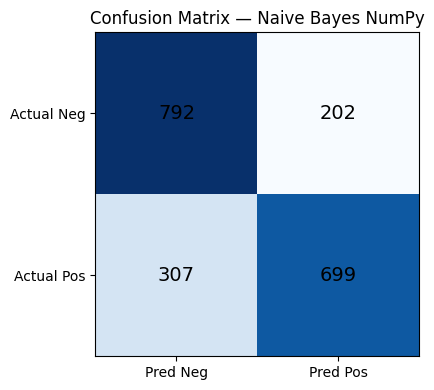

In [7]:
tp = np.sum((y_pred_test==1)&(y_test==1)); tn = np.sum((y_pred_test==0)&(y_test==0))
fp = np.sum((y_pred_test==1)&(y_test==0)); fn = np.sum((y_pred_test==0)&(y_test==1))
cm = np.array([[tn, fp],[fn, tp]])

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred Neg','Pred Pos'])
ax.set_yticklabels(['Actual Neg','Actual Pos'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=14)
ax.set_title('Confusion Matrix — Naive Bayes NumPy')
plt.tight_layout(); plt.show()

## 8. ROC Curve

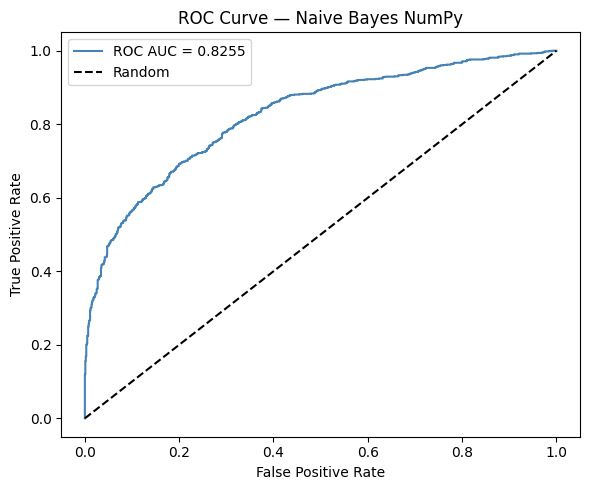

In [8]:
# Manual ROC — sort by decreasing probability and sweep threshold
order  = np.argsort(-y_proba_test)
y_s    = y_test[order]
P      = y_test.sum(); N = (y_test==0).sum()
tpr, fpr = [0.0], [0.0]
tp_c, fp_c = 0, 0
for label in y_s:
    if label == 1: tp_c += 1
    else:          fp_c += 1
    tpr.append(tp_c / P)
    fpr.append(fp_c / N)

auc = np.trapezoid(tpr, fpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'ROC AUC = {auc:.4f}')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Naive Bayes NumPy')
plt.legend(); plt.tight_layout(); plt.show()

## 9. Top Discriminative Words

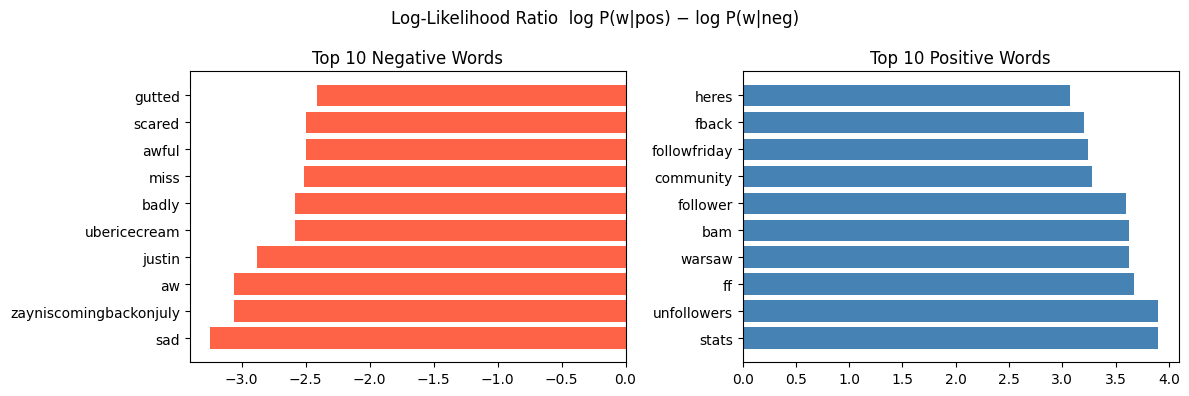

In [9]:
log_ratio = log_likelihood[1] - log_likelihood[0]   # log P(w|pos) - log P(w|neg)
order     = np.argsort(log_ratio)

top_neg_w = [vocab[i] for i in order[:10]]
top_pos_w = [vocab[i] for i in order[-10:][::-1]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.barh(top_neg_w, log_ratio[order[:10]],  color='tomato')
ax1.set_title('Top 10 Negative Words')
ax2.barh(top_pos_w, log_ratio[order[-10:][::-1]], color='steelblue')
ax2.set_title('Top 10 Positive Words')
plt.suptitle('Log-Likelihood Ratio  log P(w|pos) − log P(w|neg)')
plt.tight_layout(); plt.show()

## 10. Predict on Custom Tweets

In [10]:
def predict_tweet(tweet):
    tokens = clean(tweet)
    x      = np.zeros((1, V), dtype=np.int32)
    for w in tokens:
        if w in word2idx:
            x[0, word2idx[w]] += 1
    prob  = predict_proba(x, log_prior, log_likelihood)[0, 1]
    label = 'Positive 😊' if prob >= 0.5 else 'Negative 😞'
    print(f"Tweet:       {tweet}")
    print(f"Probability: {prob:.4f}")
    print(f"Sentiment:   {label}")
    print()

predict_tweet("I love this so much, absolutely amazing!")
predict_tweet("This is the worst day ever, I hate everything.")

Tweet:       I love this so much, absolutely amazing!
Probability: 0.8803
Sentiment:   Positive 😊

Tweet:       This is the worst day ever, I hate everything.
Probability: 0.0573
Sentiment:   Negative 😞



## 11. Save Model to `../Models/`

Saves vocabulary (as text), log priors, and log likelihood matrix as a compressed `.npz` file.

In [11]:
save_path = '../Models/naive_bayes_numpy.npz'
np.savez_compressed(
    save_path,
    vocab          = np.array(vocab),          # (V,) string array
    log_prior      = log_prior,                # (2,)
    log_likelihood = log_likelihood            # (2, V)
)

size_kb = os.path.getsize(save_path) / 1024
print(f"Model saved → {save_path}  ({size_kb:.1f} KB)")

Model saved → ../Models/naive_bayes_numpy.npz  (40.8 KB)


## 12. Reload & Verify

In [12]:
loaded         = np.load('../Models/naive_bayes_numpy.npz', allow_pickle=True)
vocab_r        = loaded['vocab'].tolist()
word2idx_r     = {w: i for i, w in enumerate(vocab_r)}
log_prior_r    = loaded['log_prior']
log_like_r     = loaded['log_likelihood']
V_r            = len(vocab_r)

def predict_tweet_r(tweet):
    tokens = clean(tweet)
    x      = np.zeros((1, V_r), dtype=np.int32)
    for w in tokens:
        if w in word2idx_r:
            x[0, word2idx_r[w]] += 1
    prob  = predict_proba(x, log_prior_r, log_like_r)[0, 1]
    label = 'Positive 😊' if prob >= 0.5 else 'Negative 😞'
    print(f"[Reloaded] {tweet[:50]}...  →  {label}  ({prob:.4f})")

predict_tweet_r("I love this so much, absolutely amazing!")
predict_tweet_r("This is the worst day ever, I hate everything.")

[Reloaded] I love this so much, absolutely amazing!...  →  Positive 😊  (0.8803)
[Reloaded] This is the worst day ever, I hate everything....  →  Negative 😞  (0.0573)
